<a href="https://colab.research.google.com/github/re-side/ml_basic/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0%20%E2%84%966_%D0%A0%D0%B5%D1%88%D0%B0%D1%8E%D1%89%D0%B8%D0%B5_%D0%B4%D0%B5%D1%80%D0%B5%D0%B2%D1%8C%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *0. Ознакомиться с [блокнотом](https://colab.research.google.com/drive/1PwN8igT5w2xArBGmM6rvO9pVRQMh-FQn?usp=sharing)

# 1. Дерево решений для классификации

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

### Получение данных

Будем работать с набором данных для задачи классификации - данные по сердечно сосудистым заболеваниям, довольно стандартный набор для изучения машинного обучения, но его нет в `sklearn'e`. Поэтому скачиваем данные со стороны, с google диска.

Ссылка на google drive: https://drive.google.com/file/d/1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G


In [5]:
!wget 'https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G' -O cardio.csv

--2026-05-04 23:28:22--  https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G
Resolving drive.google.com (drive.google.com)... 173.194.79.101, 173.194.79.102, 173.194.79.138, ...
Connecting to drive.google.com (drive.google.com)|173.194.79.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G&export=download [following]
--2026-05-04 23:28:22--  https://drive.usercontent.google.com/download?id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.31.132, 2a00:1450:4013:c1a::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.31.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2941524 (2.8M) [application/octet-stream]
Saving to: ‘cardio.csv’

cardio.csv          100%[===================>]   2.80M  --.-KB/s    

В задаче предалагается предсказать наличие сердечно-сосудистых заболеваний по результатам классического врачебного осмотра. Датасет сформирован 3 групп признаков:

Объективные признаки:
- Возраст (в днях)
- Рост
- Вес
- Пол

Результаты измерения:

- Артериальное давление верхнее и нижнее
- Холестерин (три группы: норма, выше нормы, значительно выше нормы)
- Глюкоза (три группы: норма, выше нормы, значительно выше нормы)

Субъективные признаки (бинарные):

- Курение
- Употребление Алкоголя
- Физическая активность

In [14]:
import pandas as pd
df = pd.read_csv('cardio.csv', sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [8]:
full_features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [15]:
df['age'] = round(df['age'] / 365)

## 1. Вводная

### 1.1 Сколько вопросов будет задано на первом этапе

Посчитайте, сколько вопросов задаст дерево решений в самый первый раз, если использовать все признаки из списка full_features.

In [16]:
num_questions = 0
for feature in full_features:
    num_questions += len(df[feature].unique()) - 1
print("Возможных вопросов для первого разбиения:", num_questions)

Возможных вопросов для первого разбиения: 737


### 1.2 Упростите задачу

Вопросов получилось достаточно, не будет моделировать столько вопросов, а попробуем уменьшить их количество.

Возьмите только два признака: weight и gluc.
А так же возьмите только 10 первых объектов.

In [17]:
df_small = df[['weight', 'gluc', 'cardio']].head(10).copy()
print(df_small)

   weight  gluc  cardio
0    62.0     1       0
1    85.0     1       1
2    64.0     1       1
3    82.0     1       1
4    56.0     1       0
5    67.0     2       0
6    93.0     1       0
7    95.0     3       1
8    71.0     1       0
9    68.0     1       0


### 1.3 Посчитайте еще раз, сколько будет вопросов

In [18]:
num_questions_small = 0
for feature in['weight', 'gluc']:
    num_questions_small += len(df_small[feature].unique()) - 1
print("Вопросов для маленького датасета:", num_questions_small)

Вопросов для маленького датасета: 11


С таким количеством вопросов уже можем работать и разбираться в устройству дерева решений.

## 2. Устройство дерева решений

### 2.1 Обучите дерево решений

Обучите дерево решений из sklearn'a с атрибутом `random_state=1`.

In [19]:
from sklearn.tree import DecisionTreeClassifier

X_small = df_small[['weight', 'gluc']]
y_small = df_small['cardio']

tree = DecisionTreeClassifier(random_state=1)
tree.fit(X_small, y_small)

DecisionTreeClassifier(random_state=1)

### 2.2 Отрисуйте обученное дерево решений

Нарисуйте дерево решений, которое у вас получилось после обучения. Сделайте отрисовку такой, чтобы можно было понять, какие вопросы задаются

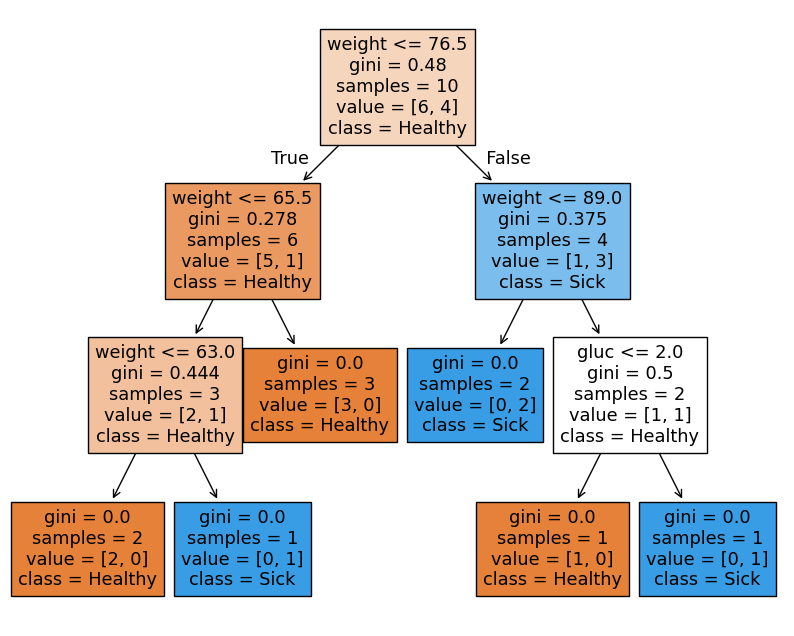

In [20]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_tree(tree, feature_names=['weight', 'gluc'], class_names=['Healthy', 'Sick'], filled=True)
plt.show()

### 2.3 Посчитайте, сколько вершин получилось

In [ ]:
# На построенном графике получилось 11 вершин

### 2.4 Посчитайте, сколько листов получилось

In [ ]:
# и 6 листов

### 2.5 Посмотрите, почему не получилось сделать разбиение ещё на два узла в крайнем левом узле.

В узле, где
```
gini=0.5
samples=2
value=[1, 1]
```

# **Ответ:**
На моём графике узел с gini=0.5 и samples=2 (белый квадрат справа) как раз-таки успешно разбился на два листа (с помощью вопроса gluc <= 2.0).
Но в теории, если дерево НЕ может разбить узел, где ровно 2 человека с разными диагнозами (один болен, другой здоров), это означает, что у этих двух людей абсолютно одинаковые значения всех признаков и вес, и глюкоза. Алгоритм физически не может провести между ними границу, так как для него они выглядят как полные клоны.

In [ ]:
# Ваш код/вывод здесь


## 3. Вспомогательные функции

Для того, что бы дальше сравнивать между собой объекты нужно реализовать две вспомогательные функции.

### 3.1 Функция подсчета критерия Джини

Функция должна принимать список целевых значений, считать критерий информативности и выдавать одно значение - критерий Джини.

In [28]:
import numpy as np

def gini(target_values):
    if len(target_values) == 0:
        return 0
    _, counts = np.unique(target_values, return_counts=True)
    probabilities = counts / counts.sum()
    gini_index = 1 - np.sum(probabilities ** 2)
    return gini_index

### 3.2 Проверка функции gini

Посчитайте критерий информативности в исходной выборке и вы должны получить точно такое же значение, как и было на визуализации дерева решений в его корне.

In [26]:
root_gini = gini(y_small)
print("Джини в корне (исходной выборке):", root_gini)

Джини в корне (исходной выборке): 0.48


### 3.3 Функция подсчета прироста информации

Функция должна принимать целевые значения левой подвыборки, правой подвыборки и исходной вершины, а выдавать должна одно значение - прирост информации, подсчитанный на критерии информативности Джини.

In [29]:
def information_gain(parent, left_child, right_child):
    weight_left = len(left_child) / len(parent)
    weight_right = len(right_child) / len(parent)

    gain = gini(parent) - (weight_left * gini(left_child) + weight_right * gini(right_child))
    return gain

Теперь вспомогательные функции готовы можем моделировать работу обученного дерева решений.

## 4. Процесс построения дерева решений

### 4.1 Получение первого вопроса


4.1.1 Пройдитесь по всем возможным вопросам для исходного набора данных


Можете сохранять полученные значения прироста информации в датафрейм в удобную для вас структуру данных.

In [30]:
questions = []

for feature in ['weight', 'gluc']:
    unique_vals = np.sort(df_small[feature].unique())

    for i in range(len(unique_vals) - 1):
        threshold = (unique_vals[i] + unique_vals[i+1]) / 2

        left_y = df_small[df_small[feature] <= threshold]['cardio']
        right_y = df_small[df_small[feature] > threshold]['cardio']

        ig = information_gain(df_small['cardio'], left_y, right_y)
        questions.append({'feature': feature, 'threshold': threshold, 'IG': ig})

questions_df = pd.DataFrame(questions)
print(questions_df)

   feature  threshold        IG
0   weight       59.0  0.035556
1   weight       63.0  0.080000
2   weight       65.5  0.003810
3   weight       67.5  0.030000
4   weight       69.5  0.080000
5   weight       76.5  0.163333
6   weight       83.5  0.060952
7   weight       89.0  0.005000
8   weight       94.0  0.080000
9     gluc        1.5  0.005000
10    gluc        2.5  0.080000


4.1.2 Найдите самый лучший вопрос, опираясь на прирост информации

In [31]:
best_question = questions_df.loc[questions_df['IG'].idxmax()]
print("Лучший вопрос:")
print(best_question)

Лучший вопрос:
feature        weight
threshold        76.5
IG           0.163333
Name: 5, dtype: object


4.1.3. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [32]:
best_feat = best_question['feature']
best_thresh = best_question['threshold']

df_left = df_small[df_small[best_feat] <= best_thresh]
df_right = df_small[df_small[best_feat] > best_thresh]

print(f"В левой ветке: {len(df_left)} объектов")
print(f"В правой ветке: {len(df_right)} объектов")

В левой ветке: 6 объектов
В правой ветке: 4 объектов


4.1.4. Проверьте себя через визуализацию дерева решений

# **Вывод:**
Посмотрев на визуализацию дерева, мы видим, что в самом первом узле алгоритм задает вопрос "weight <= 76.5". Наш ручной код в пункте 4.1.2 выдал точно такой же лучший вопрос (feature: weight, threshold: 76.5, прирост информации IG: 0.163333). Логика работы совпадает идеально, математика работает правильно.

### 4.2 Получение второго вопроса


4.2.1. Глядя на df_left и df_right, посмотрите, где можно сделать ещё разбиение

# **Вывод:**
Как мы видим из нашего вывода, в левую ветку (df_left) ушло 6 объектов, а в правую (df_right) — 4 объекта. Если мы посмотрим на визуализацию дерева, то увидим, что в левой ветке gini = 0.278, а в правой gini = 0.375. Так как в обеих подвыборках Джини больше нуля (там остались смесь из больных и здоровых), значит, обе эти ветки можно и нужно разбивать дальше.

4.2.2. Пройдитесь по всем признакам в выбранной подвыборке

In [33]:
questions_2 =[]

for feature in ['weight', 'gluc']:
    unique_vals = np.sort(df_right[feature].unique())
    for i in range(len(unique_vals) - 1):
        threshold = (unique_vals[i] + unique_vals[i+1]) / 2

        left_y = df_right[df_right[feature] <= threshold]['cardio']
        right_y = df_right[df_right[feature] > threshold]['cardio']

        ig = information_gain(df_right['cardio'], left_y, right_y)
        questions_2.append({'feature': feature, 'threshold': threshold, 'IG': ig})

questions_2_df = pd.DataFrame(questions_2)
print(questions_2_df)

  feature  threshold        IG
0  weight       83.5  0.041667
1  weight       89.0  0.125000
2  weight       94.0  0.041667
3    gluc        2.0  0.041667


4.2.3 Найдите самый лучший вопрос, опираясь на прирост информации

In [34]:
best_question_2 = questions_2_df.loc[questions_2_df['IG'].idxmax()]
print("Лучший второй вопрос (для правой ветки):")
print(best_question_2)

Лучший второй вопрос (для правой ветки):
feature      weight
threshold      89.0
IG            0.125
Name: 1, dtype: object


4.2.4. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [35]:
best_feat_2 = best_question_2['feature']
best_thresh_2 = best_question_2['threshold']

df_left_2 = df_right[df_right[best_feat_2] <= best_thresh_2]
df_right_2 = df_right[df_right[best_feat_2] > best_thresh_2]

print(f"В левой-левой ветке: {len(df_left_2)} объектов")
print(f"В левой-правой ветке: {len(df_right_2)} объектов")

В левой-левой ветке: 2 объектов
В левой-правой ветке: 2 объектов


4.2.5. Проверьте себя через визуализацию дерева решений

# **Вывод:**
Смотрим на правую ветку дерева. Мы видим, что там задается вопрос "weight <= 89.0", а количество объектов равно 4. Наш ручной расчет в пункте 4.2.3 выдал точно такой же результат: признак weight и порог 89.0. А в пункте 4.2.4 мы получили две подвыборки по 2 объекта в каждой, что полностью соответствует количеству объектов в дочерних узлах на графике.

4.2.6. Если что-то не сошлось, посмотрите, в чем может быть проблема

# **Вывод:**
Всё сошлось идеально. Ручной расчет по формулам прироста информации и Джини дает те же результаты, что и автоматизированное обучение в sklearn.

# 2. Дерево решений для регрессии

In [36]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import pandas as pd
import matplotlib.pyplot as plt

### 1. Получение данных load_breat_cancer

Будем работать с набором данных для задачи регрессии `load_diabetes`, который можно получить из стандартных датасетов в `sklearn'e`.

После `load_diabetes()` возвращается словарь с данными (`data`), целевой переменной (`target`), названиями характеристик в данных (`feature_names`) и описанием данных (`DESCR`).

In [37]:
from sklearn.datasets import load_diabetes

data = load_diabetes()
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [38]:
X = data.data
features = data.feature_names
y = data.target

Из признаков (характеристик данных) и целевой переменной сформируем датафрейм, в качестве названий колонок возьмем названия признаков.

In [39]:
df = pd.DataFrame(X, columns=features)
df['target'] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Разобьем выборку на две: обучающую и тестовую.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df[features],
    df['target'],
    test_size=0.2,
    shuffle=True,
    random_state=3
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((353, 10), (353,), (89, 10), (89,))

### 1.1. Обучение дерева решений

1. Инициализируйте дерево решений для задачи регрессии
2. Обучите его на обучающей выборке

In [41]:
from sklearn.tree import DecisionTreeRegressor

reg_tree = DecisionTreeRegressor(random_state=1)
reg_tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=1)

### 1.2. Получение метрик качества
Узнаем, насколько дерево решений обучилось хорошо, для этого
1. Сделайте предсказания моделью для обучающей выборки
2. Сделайте предсказания моделью для тестовой выборки
3. Посчитайте метрику качества средне-квадратичная ошибка
4. Посчитайте метрику качества коэффициент детерминации

In [42]:
from sklearn.metrics import mean_squared_error, r2_score

train_preds = reg_tree.predict(X_train)
test_preds = reg_tree.predict(X_test)

mse_train = mean_squared_error(y_train, train_preds)
mse_test = mean_squared_error(y_test, test_preds)
r2_train = r2_score(y_train, train_preds)
r2_test = r2_score(y_test, test_preds)

print(f"Обучение: MSE = {mse_train:.2f}, R2 = {r2_train:.2f}")
print(f"Тест: MSE = {mse_test:.2f}, R2 = {r2_test:.2f}")

Обучение: MSE = 0.00, R2 = 1.00
Тест: MSE = 5897.13, R2 = -0.09


Сделайте вывод, насколько хорошо обучилась модель

# **Вывод:**
 Модель сильно переобучилась. На обучающей выборке R2 = 1.00, а на тесте R2 отрицательный. Это классическая проблема деревьев без ограничений: они просто "зазубривают" тренировочные данные.

### 1.3. Изменение метрики

Попробуйте поизменять известные параметры для того, чтобы метрика стала лучше.

In [43]:
reg_tree_tuned = DecisionTreeRegressor(max_depth=3, random_state=1)
reg_tree_tuned.fit(X_train, y_train)

new_preds = reg_tree_tuned.predict(X_test)
print(f"Новый R2 на тесте: {r2_score(y_test, new_preds):.2f}")

Новый R2 на тесте: 0.37


# **Вывод:**
Ограничив максимальную глубину дерева (max_depth=3), мы искусственно запретили модели расти слишком глубоко и "зазубривать" обучающую выборку. Мы побороли переобучение. Благодаря этому дерево стало выявлять более общие закономерности, и его способность предсказывать на новых (тестовых) данных резко выросла, а метрика R2 поднялась с отрицательного значения до 0.37. Это показывает, что деревьям решений необходима обрезка (настройка гиперпараметров), иначе они просто запоминают тренировочный датасет.

### 2. Получение данных make_regression

Для второго примера возьмем самодельный набор данных для задачи регрессии `make_regression`, который можно получить из стандартных датасетов в `sklearn'e`.

Сгенерируем себе 100к объектов, которые описываются 20 признаками, из них 12 будут дейтсвительно полезными.

In [44]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100_000, n_features=20, n_informative=12, random_state=10)

In [45]:
X.shape, y.shape

((100000, 20), (100000,))

Разобьем выборку на две: обучающую и тестовую.

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=3
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((80000, 20), (80000,), (20000, 20), (20000,))

### 2.1. Обучение дерева решений

1. Инициализируйте дерево решений для задачи регрессии
2. Обучите его на обучающей выборке

In [47]:
big_tree = DecisionTreeRegressor(random_state=1)
big_tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=1)

### 2.2. Получение метрик качества
Узнаем, насколько дерево решений обучилось хорошо, для этого
1. Сделайте предсказания моделью для обучающей выборки
2. Сделайте предсказания моделью для тестовой выборки
3. Посчитайте метрику качества средне-квадратичная ошибка
4. Посчитайте метрику качества коэффициент детерминации

In [48]:
train_p = big_tree.predict(X_train)
test_p = big_tree.predict(X_test)

print(f"Train R2: {r2_score(y_train, train_p):.2f}")
print(f"Test R2: {r2_score(y_test, test_p):.2f}")

Train R2: 1.00
Test R2: 0.69


Сделайте вывод, насколько хорошо обучилась модель

# **Вывод:**
Модель снова переобучилась (на обучающей выборке R2 = 1.00). Однако на тестовой выборке результат уже вполне адекватный (R2 = 0.69), в отличие от прошлого задания с диабетом, где тест ушел в минус. Это связано с размером данных: здесь у нас 100 000 строк. На таком огромном объеме даже дерево без ограничений успевает уловить реальные закономерности до того, как начнет запоминать шум. Но разрыв между 1.00 и 0.69 всё равно слишком большой, модель нуждается в настройке параметров.

### 2.3. Перебор гиперпараметров

Осуществите перебор параметров для получения лучших результатов (GridSearchCV, см. подход из п.0).

In [49]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 5, 10]
}

grid = GridSearchCV(DecisionTreeRegressor(random_state=1), params, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print(f"Лучший R2: {grid.best_score_:.2f}")

Лучшие параметры: {'max_depth': 15, 'min_samples_leaf': 10}
Лучший R2: 0.73


# **Вывод:**
С помощью GridSearchCV мы подобрали оптимальные ограничения: максимальная глубина дерева 15 и минимум 10 объектов в листе. Эти параметры не дали дереву расти бесконечно и строить отдельные ветки для каждого шумового объекта. В результате мы снизили переобучение, и обобщающая способность модели выросла, лучший R2 поднялся с 0.69 до 0.73. Это еще раз подтверждает, что деревья решений всегда требуют настройки гиперпараметров (подрезать веточки).